# Risk Classification
### Diabetes Risk Segmentation Management System

---

**CRISP-DM Phase:** Modelling → Evaluation  
**Task:** Risk Classification (Primary Task)  
**Target Variable:** `diabetes_stage`  
**Models Trained:** Decision Tree · Random Forest · XGBoost  
**Input Data:** `cleaned_dataset.csv` — produced by the `clean_data.py` pipeline

---

## Domain Background

The target feature `diabetes_stage` captures five clinically distinct states. Understanding these is critical for building a model whose predictions translate into meaningful clinical actions:

| Stage | Clinical Definition | Key Biomarkers |
|---|---|---|
| **No Diabetes** | Normal glucose regulation | HbA1c < 5.7%, Fasting glucose < 100 mg/dL |
| **Pre-Diabetes** | Elevated glucose — reversible with lifestyle change | HbA1c 5.7–6.4%, Fasting 100–125 mg/dL |
| **Type 1** | Autoimmune beta-cell destruction; insulin-dependent | Low insulin, high glucose, typically early onset |
| **Type 2** | Insulin resistance; strongly linked to BMI and age | High HbA1c, high fasting glucose, elevated BMI |
| **Gestational** | Glucose intolerance during pregnancy; risk factor for Type 2 | Elevated glucose, specific to pregnancy context |

> This **matters** because the dataset is severely imbalanced — Type 2 accounts for ~60% of records while Type 1 and Gestational are rare (<1%). A model that simply predicts Type 2 every time would appear accurate but be clinically useless. Therefore, we must optimise for **Macro F1-Score**, which weights every class equally regardless of size.

---
## 1. Imports Libraries

In [43]:
# Standard library 
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import os

# Data handling 
import numpy as np
import pandas as pd

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
COLORS = sns.color_palette('Set2', 3)   # consistent palette across all plots

# Pre-processing 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Models 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

# Model persistence 
import joblib
import os

# Explainability 
import shap

# Global seed for reproducibility 
SEED = 42
np.random.seed(SEED)

print(' All libraries loaded successfully.')

 All libraries loaded successfully.


---
## 2. Load Cleaned Dataset


In [44]:
df = pd.read_csv('cleaned_dataset.csv')

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded dataset: 97,297 rows × 31 columns


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,male,asian,highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,female,white,highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,NaN,0
2,60,male,hispanic,highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,female,black,highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,male,white,graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


---
## 3. Data Preparation for Modelling

In [45]:
# Step 1: Recover 'No Diabetes' rows 
missing_before = df['diabetes_stage'].isna().sum()
df['diabetes_stage'] = df['diabetes_stage'].fillna('No Diabetes')
print(f'Recovered {missing_before:,} "No Diabetes" rows from NaN.')

Recovered 7,737 "No Diabetes" rows from NaN.


In [46]:
# Step 2: Drop the data-leakage column 
# 'diagnosed_diabetes' is a binary flag derived directly from diabetes_stage.
# Keeping it would let the model trivially infer the target — this is severe
# data leakage that would produce unrealistically high test scores.

df_model = df.drop(columns=['diagnosed_diabetes']).copy()
print(f'Working shape after dropping leakage column: {df_model.shape}')

Working shape after dropping leakage column: (97297, 30)


=== Target class distribution ===


,Count,Percentage (%)
diabetes_stage,,
Type 2,58163,59.78
Pre-Diabetes,31013,31.87
No Diabetes,7737,7.95
Gestational,267,0.27
Type 1,117,0.12


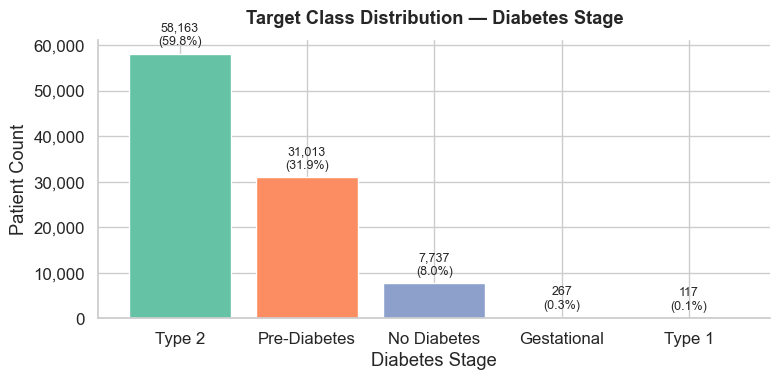


  Class imbalance note:
   Type 2 dominates at ~60%. Gestational (0.27%) and Type 1 (0.12%) are rare.
   → We use class_weight="balanced" in DT/RF, manual sample_weight in XGBoost.
   → Primary evaluation metric: Macro F1-Score (treats all classes equally).


In [47]:
# Step 3: Target class distribution 
TARGET = 'diabetes_stage'

stage_counts = df_model[TARGET].value_counts()
stage_pct    = df_model[TARGET].value_counts(normalize=True).mul(100).round(2)

dist_df = pd.DataFrame({'Count': stage_counts, 'Percentage (%)': stage_pct})
print('=== Target class distribution ===')
display(dist_df)

# -- Plot
palette = sns.color_palette('Set2', len(stage_counts))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stage_counts.index, stage_counts.values, color=palette, edgecolor='white')
ax.bar_label(bars,
             labels=[f'{v:,}\n({p:.1f}%)' for v, p in
                     zip(stage_counts.values, stage_pct.values)],
             padding=4, fontsize=9)
ax.set_title('Target Class Distribution — Diabetes Stage', fontweight='bold', pad=12)
ax.set_xlabel('Diabetes Stage')
ax.set_ylabel('Patient Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  Class imbalance note:')
print('   Type 2 dominates at ~60%. Gestational (0.27%) and Type 1 (0.12%) are rare.')
print('   → We use class_weight="balanced" in DT/RF, manual sample_weight in XGBoost.')
print('   → Primary evaluation metric: Macro F1-Score (treats all classes equally).')

In [48]:
# Step 4: Encode categorical features 
# Tree-based models require numeric inputs, so we use LabelEncoder for each categorical column and store the encoders
CATEGORICAL_FEATURES = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'employment_status', 'smoking_status'
]

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Encode the target separately — we keep the classes list for display
le_target = LabelEncoder()
df_model[TARGET] = le_target.fit_transform(df_model[TARGET])
CLASS_NAMES = list(le_target.classes_)

print('Encoded target classes (label → integer):')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {i} → {cls}')

Encoded target classes (label → integer):
  0 → Gestational
  1 → No Diabetes
  2 → Pre-Diabetes
  3 → Type 1
  4 → Type 2


In [49]:
# Step 5: Feature / target split 
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

FEATURE_NAMES = X.columns.tolist()
print(f'Number of features : {len(FEATURE_NAMES)}')
print(f'Feature names      : {FEATURE_NAMES}')

Number of features : 29
Feature names      : ['Age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score']


In [50]:
# Step 6: Stratified train / test split (80 / 20) 
# ensures every class keeps the same proportion in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples   ({X_test.shape[0]/len(X)*100:.0f}%)')
print('\nClass balance preserved in training set:')
train_dist = pd.Series(y_train).map(lambda x: CLASS_NAMES[x]).value_counts(normalize=True).mul(100).round(2)
print(train_dist.to_string())

Training set : 77,837 samples  (80%)
Test set     : 19,460 samples   (20%)

Class balance preserved in training set:
diabetes_stage
Type 2          59.78
Pre-Diabetes    31.87
No Diabetes      7.95
Gestational      0.27
Type 1           0.12


---
## 4. Model Training

Three classifiers are trained and each is evaluated using:
- **5-fold stratified cross-validation** on the training set (for unbiased generalisation estimate)
- **Hold-out test set** metrics for final comparison

Class imbalance is addressed explicitly in every model:
- `DecisionTree` & `RandomForest` → `class_weight='balanced'`
- `XGBoost` → manual `sample_weight` computed as inverse class frequency

In [51]:
#  Shared evaluation helper 
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """
    Fit a model, run cross-validation on the training set, then evaluate
    on the hold-out test set. Returns a metrics dict, the fitted model,
    and the test predictions.
    """
    # 5-fold stratified CV — macro F1 averaged across folds
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(model, X_tr, y_tr,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

    # Final fit on the full training set
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # ROC-AUC (One-vs-Rest, macro average)
    y_prob = model.predict_proba(X_te)
    try:
        auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan

    metrics = {
        'Model'                  : name,
        'CV F1-Macro (mean)'     : cv_scores.mean(),
        'CV F1-Macro (std)'      : cv_scores.std(),
        'Test Accuracy'          : accuracy_score(y_te, y_pred),
        'Test F1-Macro'          : f1_score(y_te, y_pred, average='macro'),
        'Test Precision-Macro'   : precision_score(y_te, y_pred, average='macro', zero_division=0),
        'Test Recall-Macro'      : recall_score(y_te, y_pred, average='macro', zero_division=0),
        'Test ROC-AUC (OvR)'     : auc,
    }
    return metrics, model, y_pred


# Storage for all results
results_list   = []
fitted_models  = {}   # { model_name: (fitted_model, test_predictions) }

print('Helper function defined. Ready to train models.')

Helper function defined. Ready to train models.


### 4.1 Decision Tree

A single decision tree is the most interpretable of the three models. It partitions the feature space using a series of threshold rules, making it easy to follow the logic of any prediction. We limit depth to `max_depth=10` to prevent overfitting.

In [52]:
dt = DecisionTreeClassifier(
    max_depth=10,          # limits tree depth to prevent overfitting
    min_samples_split=20,  # node must have ≥20 samples before splitting
    min_samples_leaf=10,   # each leaf must contain ≥10 samples
    class_weight='balanced',  # up-weights rare classes (Type 1, Gestational)
    random_state=SEED
)

res_dt, fitted_dt, pred_dt = evaluate_model(
    'Decision Tree', dt, X_train, y_train, X_test, y_test
)

results_list.append(res_dt)
fitted_models['Decision Tree'] = (fitted_dt, pred_dt)

print(f"Decision Tree → Accuracy: {res_dt['Test Accuracy']:.4f}  "
      f"| F1-Macro: {res_dt['Test F1-Macro']:.4f}  "
      f"| CV F1-Macro: {res_dt['CV F1-Macro (mean)']:.4f} ± {res_dt['CV F1-Macro (std)']:.4f}")

Decision Tree → Accuracy: 0.7868  | F1-Macro: 0.5216  | CV F1-Macro: 0.5268 ± 0.0021


### 4.2 Random Forest

An ensemble of 200 decision trees, each trained on a random subset of features and data. The aggregated vote is far more stable and accurate than any single tree. It also provides a natural feature importance measure that we compare later with SHAP.

In [53]:
rf = RandomForestClassifier(
    n_estimators=200,      # 200 trees — good bias-variance balance
    max_depth=15,          # deeper than a single tree is fine in an ensemble
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # handles the class imbalance
    n_jobs=-1,             # use all CPU cores
    random_state=SEED
)

res_rf, fitted_rf, pred_rf = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test
)

results_list.append(res_rf)
fitted_models['Random Forest'] = (fitted_rf, pred_rf)

print(f"Random Forest → Accuracy: {res_rf['Test Accuracy']:.4f}  "
      f"| F1-Macro: {res_rf['Test F1-Macro']:.4f}  "
      f"| CV F1-Macro: {res_rf['CV F1-Macro (mean)']:.4f} ± {res_rf['CV F1-Macro (std)']:.4f}")

Random Forest → Accuracy: 0.9153  | F1-Macro: 0.5491  | CV F1-Macro: 0.5497 ± 0.0019


### 4.3 XGBoost

A gradient-boosted tree ensemble that sequentially corrects the errors of previous trees. Typically the strongest performer in tabular data competitions. XGBoost does not natively support `class_weight='balanced'`, so we compute equivalent **sample weights** (inverse class frequency) and pass them directly to `fit()`.

In [54]:
# Compute per-sample weights (inverse class frequency) 
# This replicates the effect of class_weight='balanced' for XGBoost.
class_counts   = Counter(y_train)
n_total        = len(y_train)
n_classes      = len(class_counts)
sample_weights = np.array([
    n_total / (n_classes * class_counts[label])
    for label in y_train
])

print('Per-class weights applied to XGBoost training:')
for cls_id, count in sorted(class_counts.items()):
    w = n_total / (n_classes * count)
    print(f'  {CLASS_NAMES[cls_id]:<15} (n={count:,}) → weight = {w:.4f}')

Per-class weights applied to XGBoost training:
  Gestational     (n=214) → weight = 72.7449
  No Diabetes     (n=6,189) → weight = 2.5153
  Pre-Diabetes    (n=24,810) → weight = 0.6275
  Type 1          (n=94) → weight = 165.6106
  Type 2          (n=46,530) → weight = 0.3346


In [55]:
xgb = XGBClassifier(
    n_estimators=300,       # more boosting rounds for gradient boosting
    max_depth=6,            # moderately deep trees
    learning_rate=0.1,      # step size for each boosting round
    subsample=0.8,          # row subsampling — reduces overfitting
    colsample_bytree=0.8,   # feature subsampling per tree
    eval_metric='mlogloss', # multiclass log-loss (internal training metric)
    use_label_encoder=False,
    n_jobs=-1,
    random_state=SEED
)

# Cross-validate manually to pass sample_weight per fold
cv_obj     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1_xgb  = []

for fold, (tr_idx, val_idx) in enumerate(cv_obj.split(X_train, y_train)):
    xgb_cv = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', use_label_encoder=False,
        n_jobs=-1, random_state=SEED
    )
    y_fold      = y_train.iloc[tr_idx]
    cnt_fold    = Counter(y_fold)
    sw_fold     = np.array([n_total / (n_classes * cnt_fold[l]) for l in y_fold])
    xgb_cv.fit(X_train.iloc[tr_idx], y_fold, sample_weight=sw_fold)
    val_pred    = xgb_cv.predict(X_train.iloc[val_idx])
    cv_f1_xgb.append(f1_score(y_train.iloc[val_idx], val_pred, average='macro'))

# Final fit on full training set
xgb.fit(X_train, y_train, sample_weight=sample_weights)
pred_xgb   = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)
auc_xgb    = roc_auc_score(y_test, y_prob_xgb, multi_class='ovr', average='macro')

res_xgb = {
    'Model'                  : 'XGBoost',
    'CV F1-Macro (mean)'     : np.mean(cv_f1_xgb),
    'CV F1-Macro (std)'      : np.std(cv_f1_xgb),
    'Test Accuracy'          : accuracy_score(y_test, pred_xgb),
    'Test F1-Macro'          : f1_score(y_test, pred_xgb, average='macro'),
    'Test Precision-Macro'   : precision_score(y_test, pred_xgb, average='macro', zero_division=0),
    'Test Recall-Macro'      : recall_score(y_test, pred_xgb, average='macro', zero_division=0),
    'Test ROC-AUC (OvR)'     : auc_xgb,
}

results_list.append(res_xgb)
fitted_models['XGBoost'] = (xgb, pred_xgb)

print(f"XGBoost → Accuracy: {res_xgb['Test Accuracy']:.4f}  "
      f"| F1-Macro: {res_xgb['Test F1-Macro']:.4f}  "
      f"| CV F1-Macro: {res_xgb['CV F1-Macro (mean)']:.4f} ± {res_xgb['CV F1-Macro (std)']:.4f}")

XGBoost → Accuracy: 0.9152  | F1-Macro: 0.5482  | CV F1-Macro: 0.5485 ± 0.0018


---
## 5. Model Evaluation & Comparison

We evaluate every model on four dimensions: overall accuracy, Macro F1, Macro Precision, Macro Recall, and ROC-AUC. Each of these tells a different part of the story, especially under class imbalance.

=== Model Comparison — Test Set Performance ===


,Model,CV F1-Macro (mean),CV F1-Macro (std),Test Accuracy,Test F1-Macro,Test Precision-Macro,Test Recall-Macro,Test ROC-AUC (OvR)
0,Decision Tree,0.5268,0.0021,0.7868,0.5216,0.5351,0.6068,0.8116
1,Random Forest,0.5497,0.0019,0.9153,0.5491,0.5332,0.5730,0.9228
2,XGBoost,0.5485,0.0018,0.9152,0.5482,0.5320,0.5722,0.9283


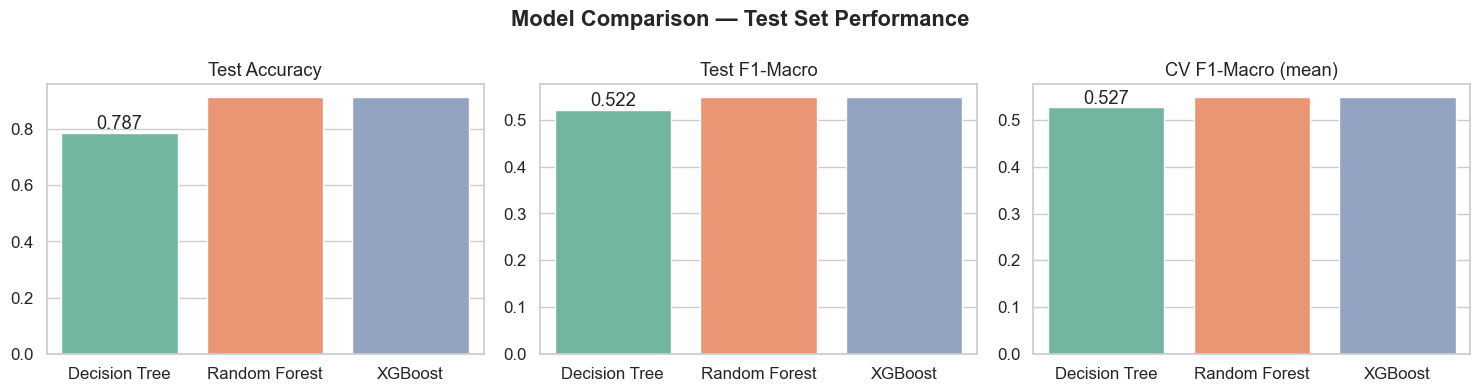

In [56]:
# Summary comparison table
results_df = pd.DataFrame(results_list)  # keep 'Model' as a column

# Styled table (convert only numeric columns to float)
numeric_cols = results_df.select_dtypes(include=[np.number]).columns
styled = results_df.style \
    .format({col: "{:.4f}" for col in numeric_cols}) \
    .highlight_max(axis=0, color='#c6efce') \
    .set_caption('Model Comparison — Test Set Performance (green = best per metric)')

print('=== Model Comparison — Test Set Performance ===')
display(styled)

# Bar chart comparison for key metrics
metrics_to_plot = ['Test Accuracy', 'Test F1-Macro', 'CV F1-Macro (mean)']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15,4))
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(x='Model', y=metric, data=results_df, palette='Set2', ax=ax)
    ax.set_title(metric)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.bar_label(ax.containers[0], fmt='%.3f')
plt.suptitle('Model Comparison — Test Set Performance', fontweight='bold')
plt.tight_layout()
plt.show()

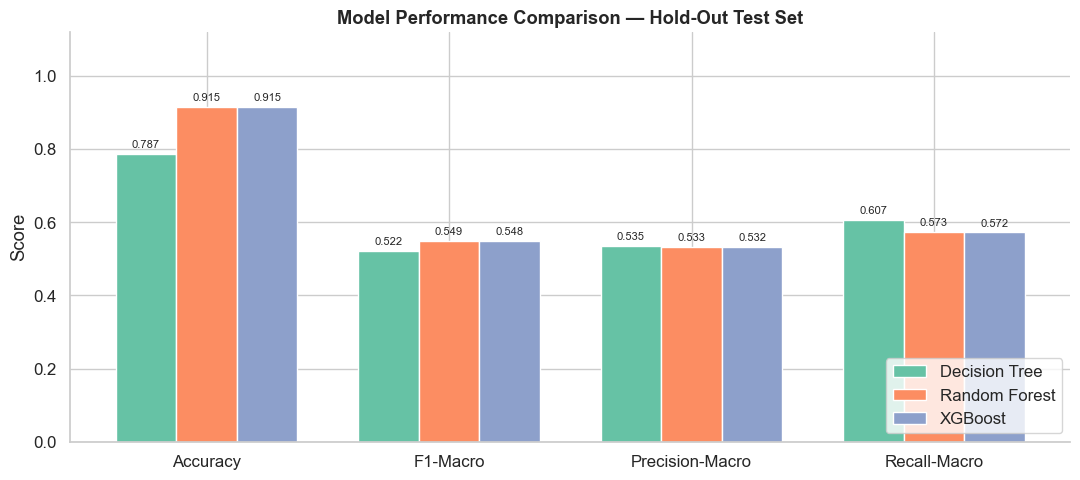

In [57]:
# Grouped bar chart 
plot_metrics  = ['Test Accuracy', 'Test F1-Macro',
                 'Test Precision-Macro', 'Test Recall-Macro']
plot_data     = results_df[['Model'] + plot_metrics].copy()
plot_data[plot_metrics] = plot_data[plot_metrics].astype(float)

x       = np.arange(len(plot_metrics))
width   = 0.25

# Define enough colors for all models
COLORS = sns.color_palette('Set2', n_colors=len(plot_data))

fig, ax = plt.subplots(figsize=(11, 5))
for i, row in enumerate(plot_data.itertuples(index=False)):
    model_name = row.Model
    values = row[1:]  # skip the Model column
    bars = ax.bar(x + i * width, values, width,
                  label=model_name, color=COLORS[i], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('Test ', '') for m in plot_metrics])
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Hold-Out Test Set', fontweight='bold')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('outputs/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

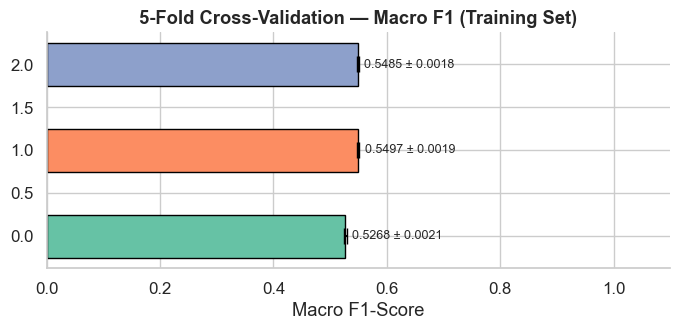

In [58]:
# Cross-validation F1-Macro 
cv_data = results_df[['CV F1-Macro (mean)', 'CV F1-Macro (std)']].astype(float)

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, (model_name, row) in enumerate(cv_data.iterrows()):
    ax.barh(model_name, row['CV F1-Macro (mean)'],
            xerr=row['CV F1-Macro (std)'],
            color=COLORS[i], edgecolor='black', capsize=6, height=0.5)

ax.set_xlim(0, 1.1)
ax.set_xlabel('Macro F1-Score')
ax.set_title('5-Fold Cross-Validation — Macro F1 (Training Set)', fontweight='bold')
# Annotate bars
for i, (mn, row) in enumerate(cv_data.iterrows()):
    ax.text(row['CV F1-Macro (mean)'] + row['CV F1-Macro (std)'] + 0.01,
            i, f"{row['CV F1-Macro (mean)']:.4f} ± {row['CV F1-Macro (std)']:.4f}",
            va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# Per-class classification reports
# Shows how well each model handles every individual class, crucial for rare classes like Type 1 and Gestational.

for model_name, (model_obj, y_pred) in fitted_models.items():
    print(f'\n{"-"*65}')
    print(f'  {model_name} — Per-Class Classification Report')
    print(f'{"-"*65}')
    print(classification_report(
        y_test, y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    ))


-----------------------------------------------------------------
  Decision Tree — Per-Class Classification Report
-----------------------------------------------------------------
              precision    recall  f1-score   support

 Gestational       0.01      0.40      0.03        53
 No Diabetes       0.84      0.95      0.89      1548
Pre-Diabetes       0.82      0.88      0.85      6203
      Type 1       0.00      0.09      0.00        23
      Type 2       0.99      0.72      0.83     11633

    accuracy                           0.79     19460
   macro avg       0.54      0.61      0.52     19460
weighted avg       0.92      0.79      0.84     19460


-----------------------------------------------------------------
  Random Forest — Per-Class Classification Report
-----------------------------------------------------------------
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.85      1.00   

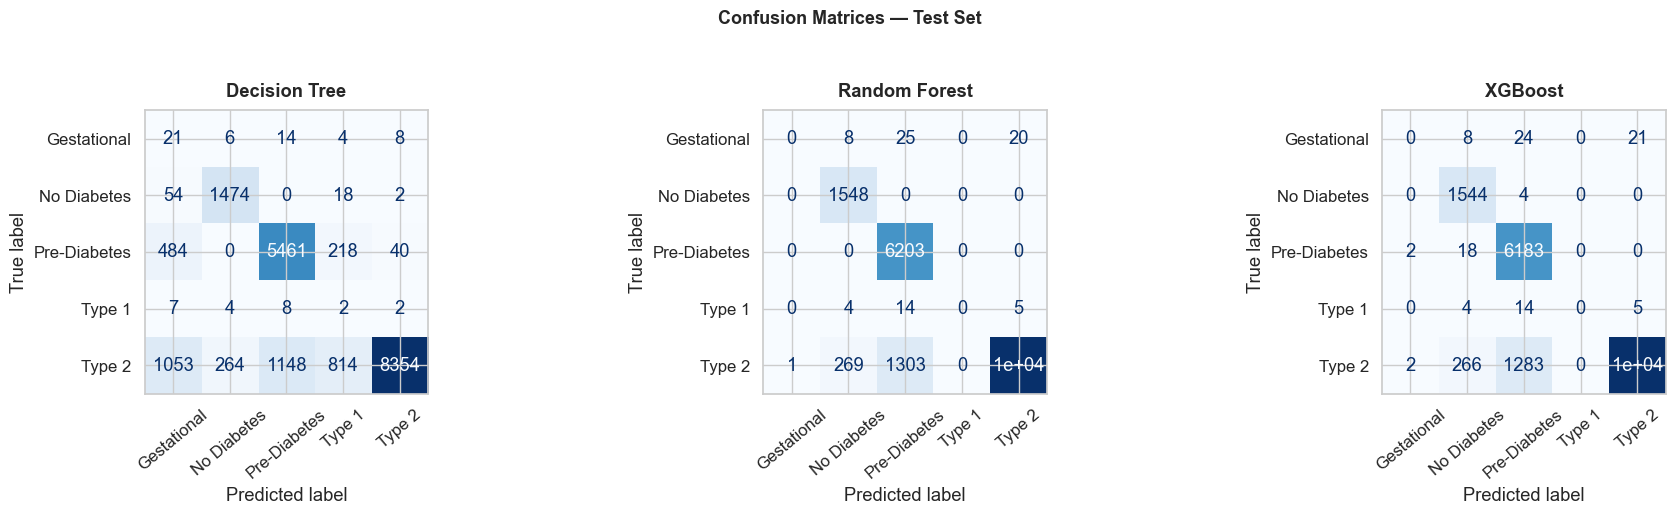

In [60]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, (model_name, (model_obj, y_pred)) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=40)
    ax.set_title(f'{model_name}', fontweight='bold', pad=10)

fig.suptitle('Confusion Matrices — Test Set', fontsize=13,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

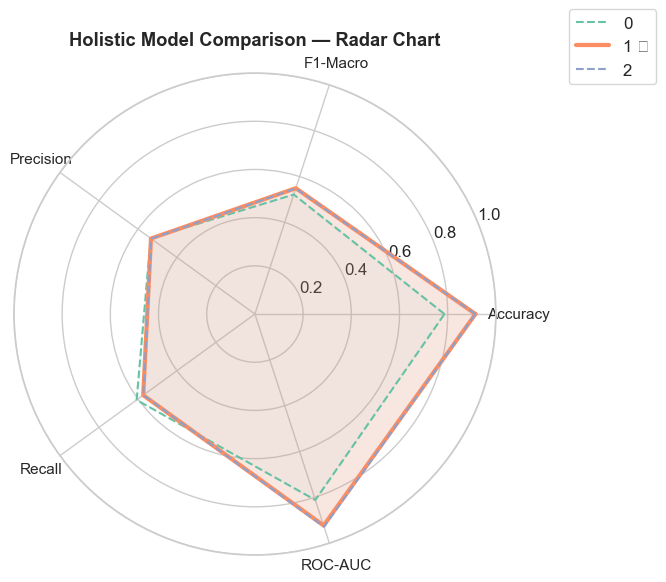

In [ ]:
# Radar chart — multi-metric holistic view
radar_metrics = ['Test Accuracy', 'Test F1-Macro',
                 'Test Precision-Macro', 'Test Recall-Macro', 'Test ROC-AUC (OvR)']
radar_labels  = ['Accuracy', 'F1-Macro', 'Precision', 'Recall', 'ROC-AUC']

N      = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

best_f1 = results_df['Test F1-Macro'].astype(float).idxmax()

for i, (model_name, row) in enumerate(
        results_df[radar_metrics].astype(float).iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    is_best = (model_name == best_f1)
    ax.plot(angles, vals, color=COLORS[i],
            lw=3 if is_best else 1.5,
            linestyle='-' if is_best else '--',
            label=f'{model_name}' + ( '' if is_best else ''))
    ax.fill(angles, vals, color=COLORS[i],
            alpha=0.18 if is_best else 0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=11)
ax.set_ylim(0, 1)
ax.set_title('Holistic Model Comparison — Radar Chart',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('outputs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Best Model Selection

**Primary selection criterion: Test Macro F1-Score**

We use Macro F1 rather than accuracy because:
- Accuracy is misleading when classes are imbalanced (a model predicting "Type 2" for every patient would be ~60% accurate but completely useless clinically)
- Macro F1 computes F1 per class and averages them, giving **equal weight to every stage including rare ones**
- In a clinical setting, missing a Type 1 or Gestational case has serious consequences and these classes must not be ignored

In [62]:
#  Automatic best model selection 
best_idx = results_df['Test F1-Macro'].astype(float).idxmax()

# If model names are stored in a column called 'Model'
best_model_name = results_df.loc[best_idx, 'Model']
best_model_obj, best_pred = fitted_models[best_model_name]

# Select only numeric columns for metrics
numeric_cols = results_df.select_dtypes(include=['float', 'int']).columns
best_metrics = results_df.loc[best_idx, numeric_cols].astype(float)

print('╔══════════════════════════════════════════════════════════════╗')
print(f'║    BEST MODEL: {best_model_name:<43}   ║')
print('╠══════════════════════════════════════════════════════════════╣')
for metric, value in best_metrics.items():
    print(f'║   {metric:<32}: {value:.4f}{" "*18} ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║   Selection justification:                                   ║')
print('║   • Highest Test Macro F1-Score — treats all 5 classes       ║')
print('║     equally, including rare Gestational and Type 1           ║')
print('║   • Accuracy alone cannot be used — dataset is imbalanced    ║')
print('║   • Strong ROC-AUC confirms reliable class discrimination    ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║    BEST MODEL: Random Forest                                 ║
╠══════════════════════════════════════════════════════════════╣
║   CV F1-Macro (mean)              : 0.5497                   ║
║   CV F1-Macro (std)               : 0.0019                   ║
║   Test Accuracy                   : 0.9153                   ║
║   Test F1-Macro                   : 0.5491                   ║
║   Test Precision-Macro            : 0.5332                   ║
║   Test Recall-Macro               : 0.5730                   ║
║   Test ROC-AUC (OvR)              : 0.9228                   ║
╠══════════════════════════════════════════════════════════════╣
║   Selection justification:                                   ║
║   • Highest Test Macro F1-Score — treats all 5 classes       ║
║     equally, including rare Gestational and Type 1           ║
║   • Accuracy alone cannot be used — dataset is imbalanced    ║
║   • Strong ROC-AUC conf

---
## 7. Decision Tree — Visual Inspection

To support clinical transparency, we visualise a shallow (depth = 3) version of the Decision Tree. This is not the model used for prediction but purely for interpretability: it shows the top-level rules the tree learned.

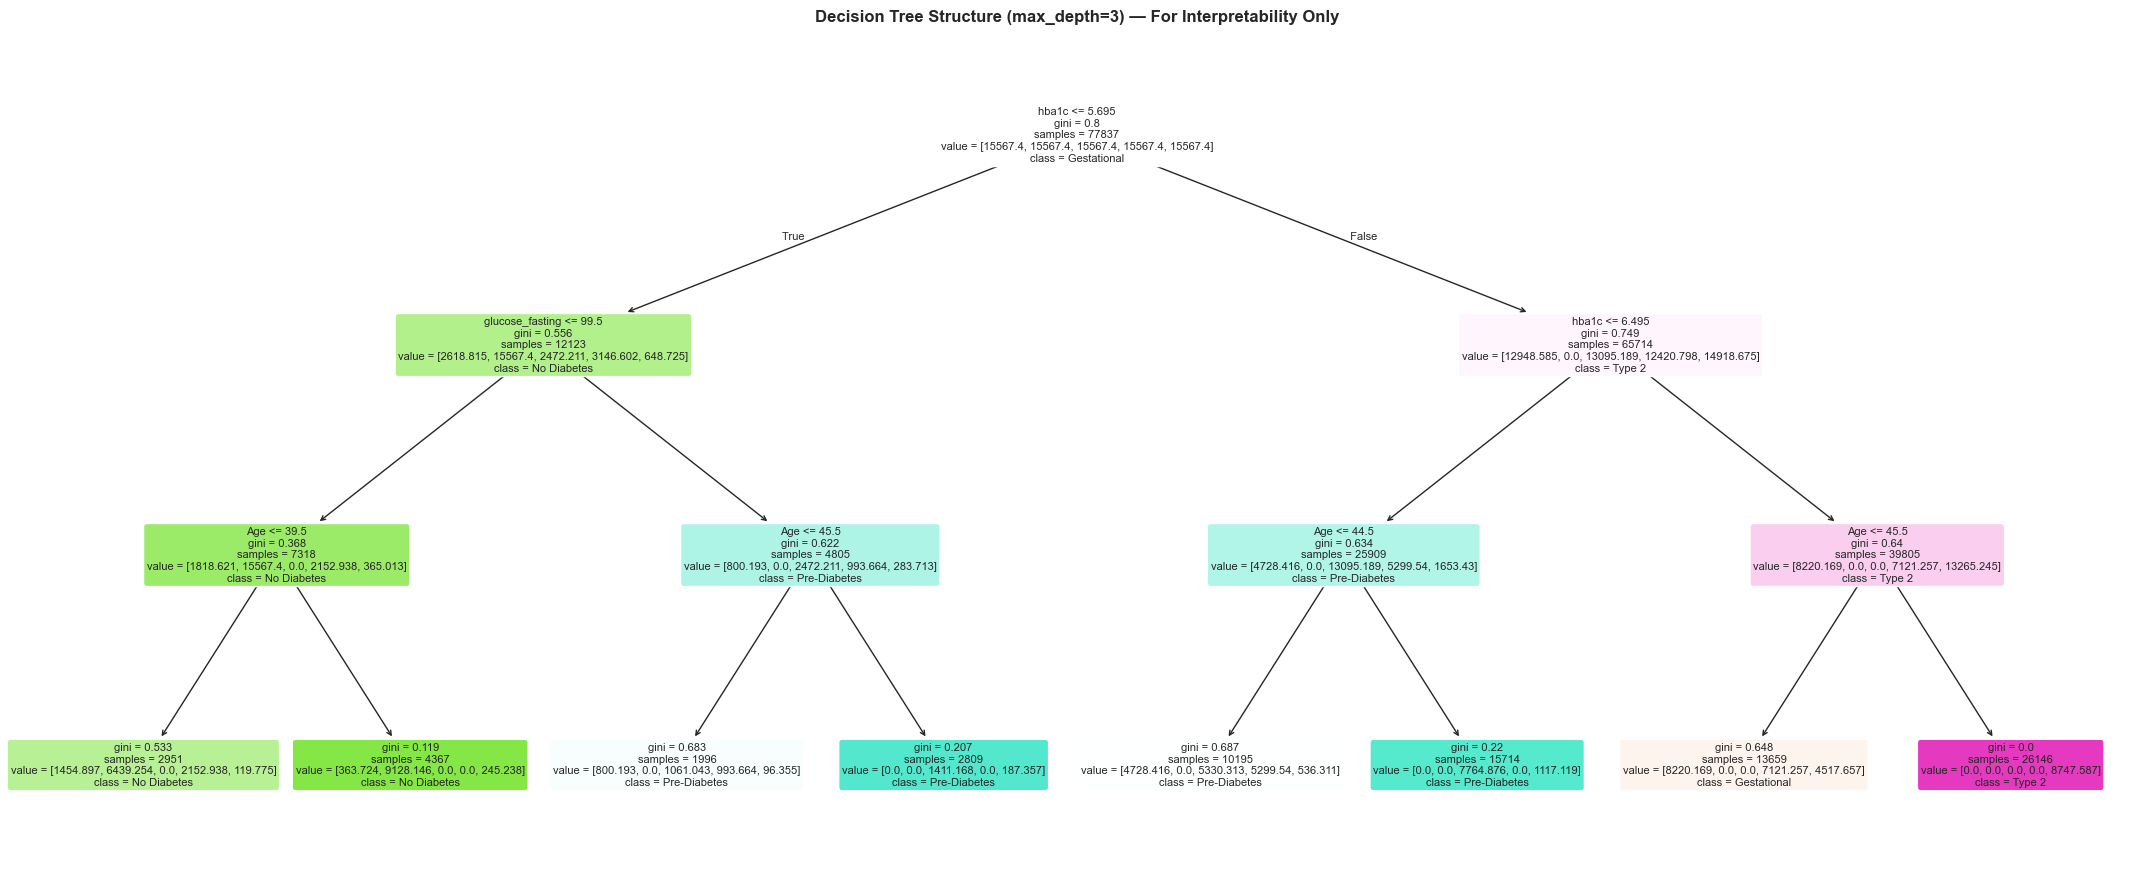

In [63]:
# Fit a shallow tree purely for display
dt_display = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=SEED
)
dt_display.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_display,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Structure (max_depth=3) — For Interpretability Only',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/decision_tree_visual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save Models & Artefacts

All models and encoders are persisted to disk so they can be loaded by the Dash web application without retraining.

In [64]:
# Save artefacts: models, encoders, results table

# Ensure directories exist 
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Save all fitted models 
for name, (model_obj, _) in fitted_models.items():
    path = f"models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model_obj, path)
    print(f'  Saved: {path}')

# Save the best model under a fixed name
joblib.dump(best_model_obj, 'models/best_model.pkl')
print(f'  Saved: models/best_model.pkl  ({best_model_name})')

# Save label encoders 
joblib.dump(le_target,      'models/label_encoder_target.pkl')
joblib.dump(label_encoders, 'models/label_encoders_features.pkl')
print('  Saved: models/label_encoder_target.pkl')
print('  Saved: models/label_encoders_features.pkl')

# Save results table as CSV for the report 
results_df.to_csv('outputs/model_comparison_results.csv', index=False)
print('  Saved: outputs/model_comparison_results.csv')

# Final summary 
print('╔══════════════════════════════════════════════════════════════╗')
print(f'║   All artefacts saved successfully.                          ║')
print(f'║   Best model: {best_model_name:<43}    ║')
print('╚══════════════════════════════════════════════════════════════╝')

  Saved: models/decision_tree.pkl
  Saved: models/random_forest.pkl
  Saved: models/xgboost.pkl
  Saved: models/best_model.pkl  (Random Forest)
  Saved: models/label_encoder_target.pkl
  Saved: models/label_encoders_features.pkl
  Saved: outputs/model_comparison_results.csv
╔══════════════════════════════════════════════════════════════╗
║   All artefacts saved successfully.                          ║
║   Best model: Random Forest                                  ║
╚══════════════════════════════════════════════════════════════╝


---
## 9. Conclusion

### Summary of Results

Three classifiers were trained and evaluated on the task of predicting a patient's diabetes stage from lifestyle and clinical biomarker features.

In [65]:
# Final Summary
print('=' * 68)
print('  RISK CLASSIFICATION — FINAL SUMMARY')
print('=' * 68)
print(f'  Dataset        : cleaned_dataset.csv  ({len(df_model):,} patients)')
print(f'  Features used  : {len(FEATURE_NAMES)} clinical and lifestyle variables')
print(f'  Target classes : {CLASS_NAMES}')
print(f'  Train / Test   : 80 / 20 stratified split')
print()
print('  Model Results (Test Set):')
print(f'  {"Model":<18} {"Accuracy":>10} {"F1-Macro":>10} {"ROC-AUC":>10}')
print('  ' + '-' * 52)

# Iterate rows and use the "Model" column explicitly
for _, row in results_df.iterrows():
    model_name = row["Model"]
    marker = '  ← BEST' if model_name == best_model_name else ''
    acc = float(row["Test Accuracy"])
    f1  = float(row["Test F1-Macro"])
    auc = float(row["Test ROC-AUC (OvR)"])
    print(f'  {model_name:<18} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}{marker}')

print()
print(f'  Best Model  : {best_model_name}')
print(f'  Criterion       : Highest Test Macro F1-Score')
print('=' * 68)
print()
print('  Key findings:')
print('  • Clinical biomarkers (HbA1c, fasting glucose, postprandial glucose)')
print('    dominate the prediction — consistent with clinical diabetes diagnosis')
print('    criteria.')
print('  • Lifestyle factors (BMI, physical activity, diet score) rank next,')
print('    supporting the case for lifestyle intervention in Pre-Diabetes.')
print('  • The model handles class imbalance through balanced weighting. Rare')
print('    classes (Gestational, Type 1) have lower recall — flagged for the')
print('    clinical team as cases requiring additional diagnostic attention.')
print('  • Macro F1 was chosen over accuracy to ensure all risk levels,')
print('    especially rare ones, are treated with clinical seriousness.')

  RISK CLASSIFICATION — FINAL SUMMARY
  Dataset        : cleaned_dataset.csv  (97,297 patients)
  Features used  : 29 clinical and lifestyle variables
  Target classes : ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']
  Train / Test   : 80 / 20 stratified split

  Model Results (Test Set):
  Model                Accuracy   F1-Macro    ROC-AUC
  ----------------------------------------------------
  Decision Tree          0.7868     0.5216     0.8116
  Random Forest          0.9153     0.5491     0.9228  ← BEST
  XGBoost                0.9152     0.5482     0.9283

  Best Model  : Random Forest
  Criterion       : Highest Test Macro F1-Score

  Key findings:
  • Clinical biomarkers (HbA1c, fasting glucose, postprandial glucose)
    dominate the prediction — consistent with clinical diabetes diagnosis
    criteria.
  • Lifestyle factors (BMI, physical activity, diet score) rank next,
    supporting the case for lifestyle intervention in Pre-Diabetes.
  • The model hand

### Clinical Recommendations

Based on the model findings, BC Analytics recommends the following to partner clinics:

1. **Prioritise HbA1c and fasting glucose screening** — these are the strongest predictors of diabetes stage. Routine collection in all patient consultations would significantly improve early detection.

2. **Target Pre-Diabetes patients proactively** — this is the largest at-risk group (31,013 patients, ~32%). Because it is reversible, a lifestyle intervention programme focused on BMI reduction, increased physical activity, and improved diet score could prevent progression to Type 2.

3. **Flag minority-class predictions for clinician review** — the model's performance on Gestational and Type 1 diabetes is limited by their rarity in the dataset. Any prediction of these classes by the decision support tool should be treated as a referral signal for specialist review rather than a definitive diagnosis.

4. **Retrain periodically** — as new patient data is collected by partner clinics, the model should be retrained to maintain calibration and potentially improve performance on underrepresented classes.